# Customer Intelligence System

**Objective** - build an end-to-end intelligence pipeline that segments entities and then predicts those segments.

**Dataset** - `Country-data.csv` (167 records, socio-economic & health indicators). Each row is treated as one *entity/record* to be profiled and scored, exactly like a customer record in a real Customer Intelligence System.

**Pipeline** - the three required techniques are chained so they reinforce each other:
- Clustering (K-Means, DBSCAN) - discover natural segments in unlabelled data.
- Segment labelling - turn the discovered clusters into a target variable.
- Classification / Ensemble (Random Forest, XGBoost) - learn to predict the segment of any new entity, giving a deployable scoring model.

## 1 - Setup and imports
- Load all libraries used across the notebook (data handling, clustering, ensemble models, plotting).
- A fixed random seed keeps every run reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from xgboost import XGBClassifier

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
%matplotlib inline

## 2 - Load the data
- Read `Country-data.csv`; if only the raw `archive.zip` is present, unzip it first.
- Keeping the loading flexible means the notebook runs whether the file is loose or still zipped.

In [2]:
import os, zipfile

CSV_NAME = "Country-data.csv"
if not os.path.exists(CSV_NAME) and os.path.exists("archive.zip"):
    with zipfile.ZipFile("archive.zip") as z:
        z.extractall(".")           # extracts Country-data.csv from the archive

df = pd.read_csv(CSV_NAME)
print("Rows, columns:", df.shape)
df.head()

Rows, columns: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 3 - Explore the data (EDA)
- Check column types, summary statistics and missing values before modelling.
- Tells us the data is clean (no nulls) and that features live on very different scales - so scaling will be needed.

In [3]:
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())
df.describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB

Missing values per column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


### 3.1 - Feature correlations
- A heatmap shows which indicators move together.
- We expect strong links (e.g. child mortality with fertility, income with GDP) - useful context for interpreting clusters later.

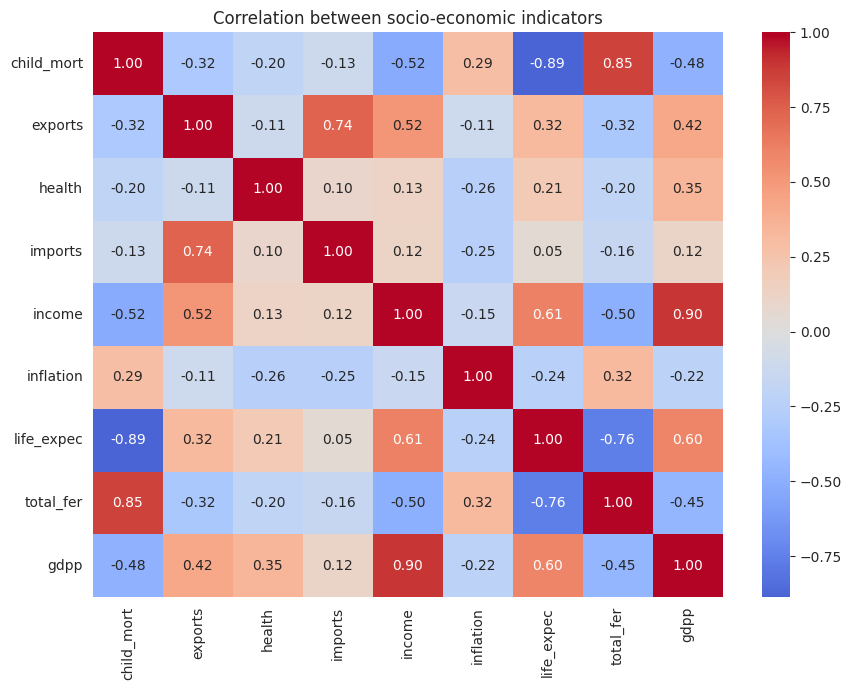

In [4]:
features = [c for c in df.columns if c != "country"]

plt.figure(figsize=(9, 7))
sns.heatmap(df[features].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between socio-economic indicators")
plt.tight_layout()
plt.show()

### 3.2 - Distribution of key drivers
- Plot the spread of the most decisive indicators.
- Highlights the wide inequality between records (a few very rich vs many poor) - the pattern clustering will pick up.

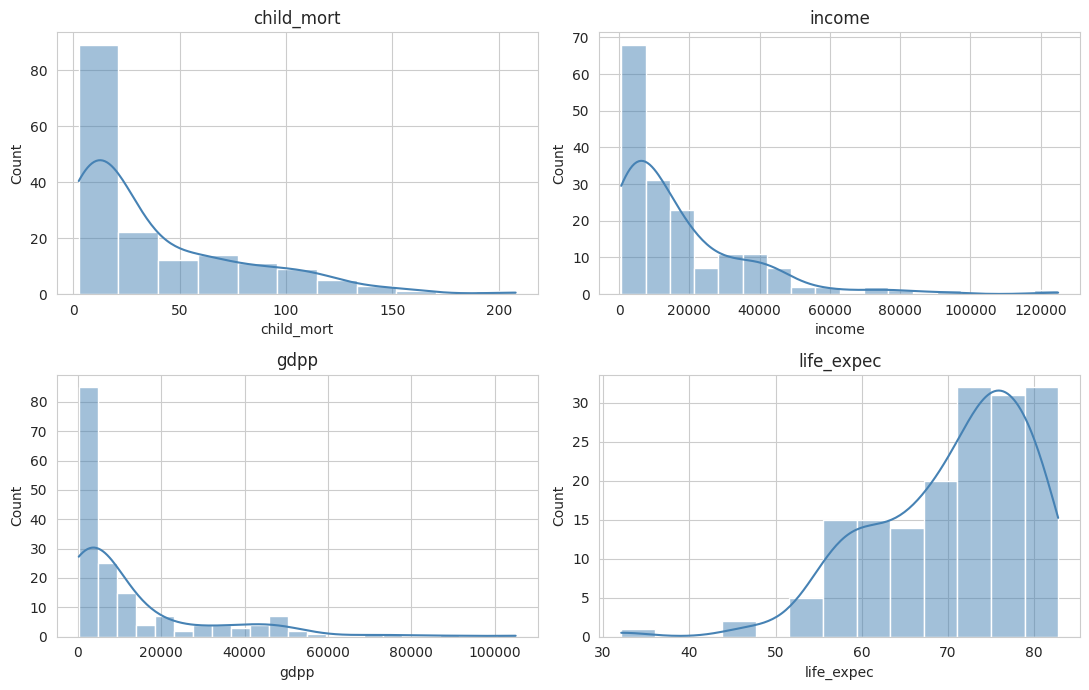

In [5]:
key = ["child_mort", "income", "gdpp", "life_expec"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), key):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 4 - Preprocessing
- Separate the `country` label from the numeric features and standardise the features (mean 0, std 1).
- Distance-based algorithms (K-Means, DBSCAN) and the models need scaled inputs so no single large-valued column dominates.

In [6]:
X_raw = df[features].copy()

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)          # scaled feature matrix used everywhere below
print("Scaled feature matrix shape:", X.shape)

Scaled feature matrix shape: (167, 9)


## 5 - Clustering with K-Means
### 5.1 - Choose the number of clusters
- Run K-Means for a range of k and record inertia (elbow) and silhouette score.
- The "elbow" plus a stable silhouette tells us the natural number of segments.

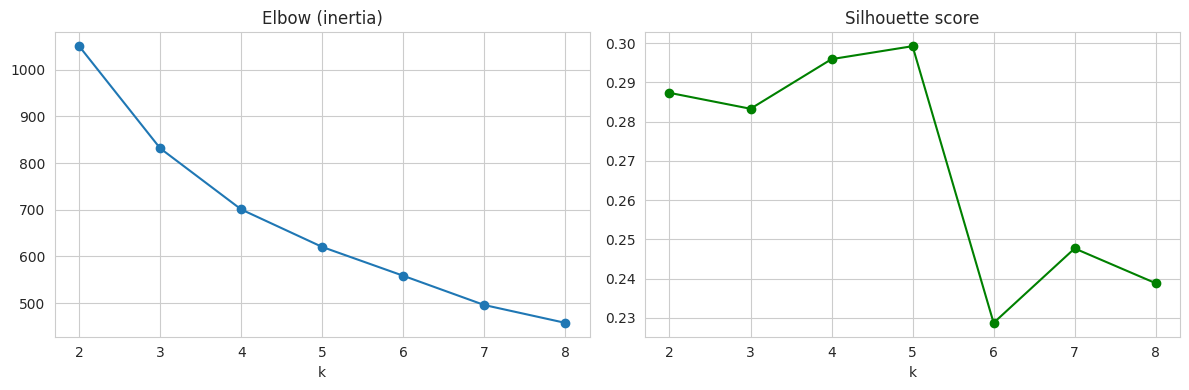

In [7]:
inertia, sil = [], []
K = range(2, 9)
for k in K:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(list(K), inertia, "o-"); a1.set_title("Elbow (inertia)"); a1.set_xlabel("k")
a2.plot(list(K), sil, "o-", color="green"); a2.set_title("Silhouette score"); a2.set_xlabel("k")
plt.tight_layout(); plt.show()

### 5.2 - Fit the final K-Means model
- The elbow bends at k = 3 and the silhouette stays healthy there, so we use 3 segments.
- Three groups also give the clearest, most actionable business story.

In [8]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans.fit_predict(X)
print("Countries per cluster:")
print(df["cluster"].value_counts().sort_index())

Countries per cluster:
cluster
0    36
1    47
2    84
Name: count, dtype: int64


### 5.3 - Profile and name the segments
- Average each indicator per cluster, then rank clusters by GDP per capita to give them meaningful names.
- Turns anonymous cluster ids into interpretable tiers (low / mid / high development), i.e. the "customer segments".

In [9]:
profile = df.groupby("cluster")[features].mean().round(1)
display(profile)

# rank clusters low -> high by GDP per capita and map to segment names
order = df.groupby("cluster")["gdpp"].mean().sort_values().index.tolist()
names = {order[0]: "Tier-1 High-Need (Underdeveloped)",
         order[1]: "Tier-2 Emerging (Developing)",
         order[2]: "Tier-3 Advanced (Developed)"}
codes = {order[0]: 0, order[1]: 1, order[2]: 2}   # ordered integer label

df["segment"] = df["cluster"].map(names)
df["segment_code"] = df["cluster"].map(codes)
print(df["segment"].value_counts())

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,5.0,58.7,8.8,51.5,45672.2,2.7,80.1,1.8,42494.4
1,93.0,29.2,6.4,42.3,3942.4,12.0,59.2,5.0,1922.4
2,21.9,40.2,6.2,47.5,12305.6,7.6,72.8,2.3,6486.5


segment
Tier-2 Emerging (Developing)         84
Tier-1 High-Need (Underdeveloped)    47
Tier-3 Advanced (Developed)          36
Name: count, dtype: int64


### 5.4 - Visualise the segments in 2D
- Compress the 9 features to 2 principal components purely for plotting.
- Confirms visually that the three K-Means segments occupy distinct regions.

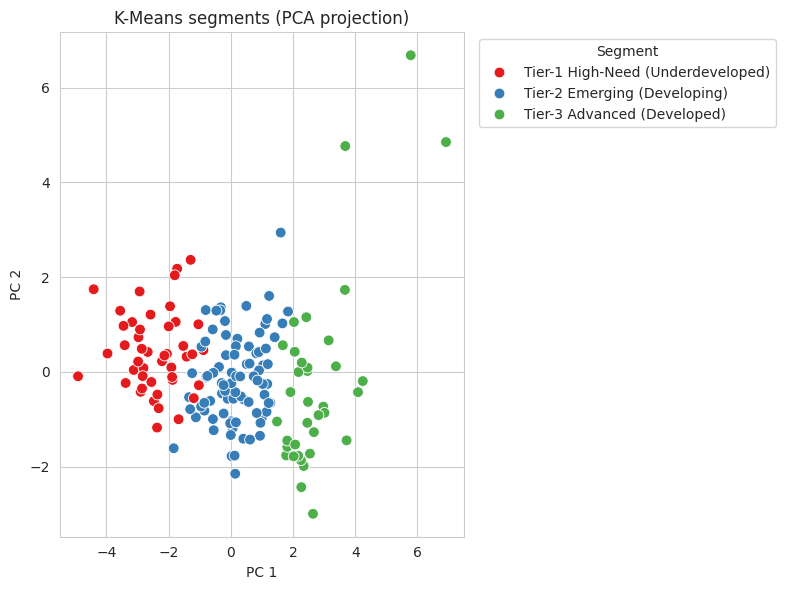

In [10]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pcs[:, 0], y=pcs[:, 1], hue=df["segment"], palette="Set1", s=60)
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.title("K-Means segments (PCA projection)")
plt.legend(title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

## 6 - Clustering with DBSCAN
- DBSCAN is density-based - it needs no preset k and labels sparse points as outliers (`-1`).
- First a k-distance plot suggests a good `eps`, then we fit and inspect how many outliers appear.

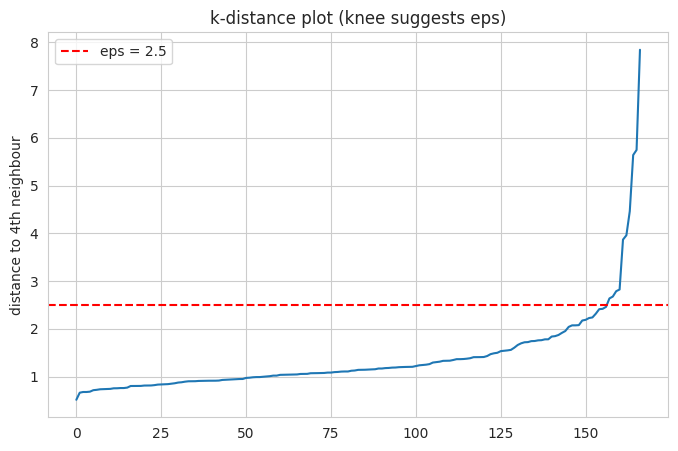

In [11]:
from sklearn.neighbors import NearestNeighbors

# k-distance plot to help choose eps
nn = NearestNeighbors(n_neighbors=4).fit(X)
dist, _ = nn.kneighbors(X)
plt.plot(np.sort(dist[:, -1]))
plt.axhline(2.5, color="red", ls="--", label="eps = 2.5")
plt.title("k-distance plot (knee suggests eps)"); plt.ylabel("distance to 4th neighbour")
plt.legend(); plt.show()

- Fit DBSCAN with the chosen `eps` and report the result.
- Here DBSCAN merges most records into one dense mass and flags only extreme records as outliers, it is useful for anomaly detection, but is less suited to clean tier segmentation than K-Means.

In [12]:
dbscan = DBSCAN(eps=2.5, min_samples=4)
db_labels = dbscan.fit_predict(X)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_outliers = int((db_labels == -1).sum())
print(f"DBSCAN dense clusters found : {n_clusters}")
print(f"Outliers (label -1)         : {n_outliers}")
print("Outlier records             :", df.loc[db_labels == -1, "country"].tolist())

DBSCAN dense clusters found : 1
Outliers (label -1)         : 6
Outlier records             : ['Haiti', 'Luxembourg', 'Malta', 'Nigeria', 'Qatar', 'Singapore']


## 7 - Build the classification target
- Use the K-Means segments as the label (`segment_code`) and the scaled indicators as features.
- Split into train / test with stratification so every segment is represented in both sets.
- This converts the unsupervised result into a supervised problem the ensemble models can learn.

In [13]:
y = df["segment_code"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
print("Train / test sizes:", X_train.shape[0], "/", X_test.shape[0])

Train / test sizes: 125 / 42


## 8 - Random Forest (bagging ensemble)
- Train a Random Forest to classify each record into its segment, then score it on the unseen test set.
- Accuracy and the per-class report tell us how cleanly the segments can be reproduced from the raw features.

In [14]:
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest accuracy :", round(accuracy_score(y_test, rf_pred), 3))
print("Weighted F1            :", round(f1_score(y_test, rf_pred, average="weighted"), 3))
print("\n", classification_report(y_test, rf_pred,
      target_names=["Tier-1", "Tier-2", "Tier-3"]))

Random Forest accuracy : 0.952
Weighted F1            : 0.953

               precision    recall  f1-score   support

      Tier-1       0.86      1.00      0.92        12
      Tier-2       1.00      0.90      0.95        21
      Tier-3       1.00      1.00      1.00         9

    accuracy                           0.95        42
   macro avg       0.95      0.97      0.96        42
weighted avg       0.96      0.95      0.95        42



### 8.1 - Confusion matrix
- It shows exactly where (if anywhere) the model confuses one segment for another.

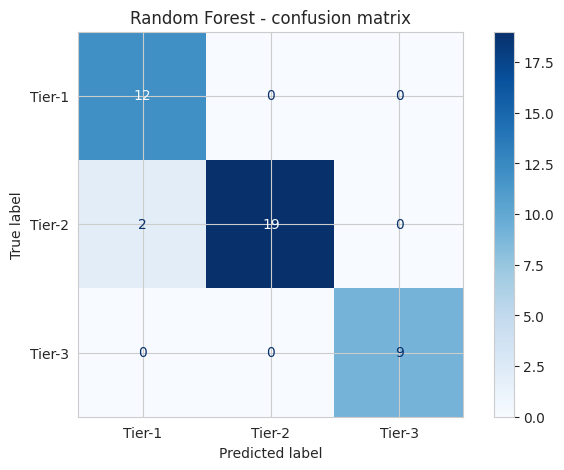

In [15]:
cm = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm, display_labels=["Tier-1", "Tier-2", "Tier-3"]).plot(cmap="Blues")
plt.title("Random Forest - confusion matrix"); plt.show()

### 8.2 - Feature importance
- The forest ranks which indicators drive the segmentation most.
- These are the levers that define an entity's tier, it matters because it is the actionable part for decision-making.

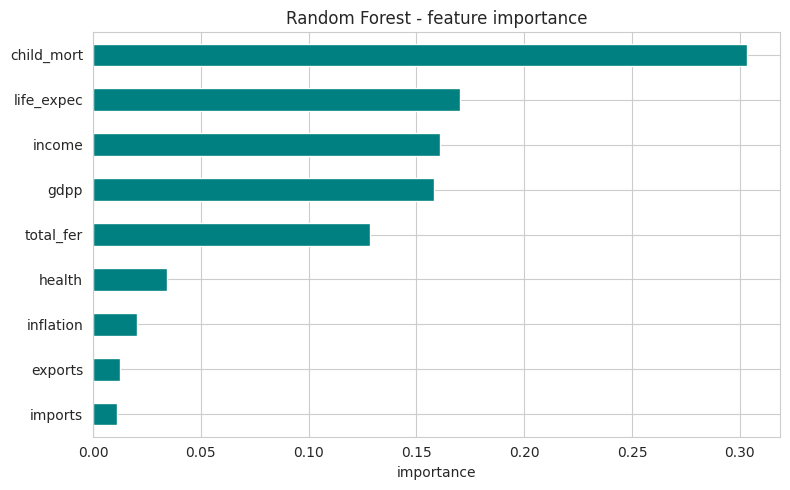

child_mort    0.303
life_expec    0.170
income        0.161
gdpp          0.158
total_fer     0.129
health        0.035
inflation     0.020
exports       0.013
imports       0.011
dtype: float64

In [16]:
imp = pd.Series(rf.feature_importances_, index=features).sort_values()
imp.plot(kind="barh", color="teal")
plt.title("Random Forest - feature importance"); plt.xlabel("importance")
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(3)

## 9 - XGBoost (boosting ensemble)
- Train a gradient-boosted model on the same split as a stronger, complementary ensemble.
- Comparing it with Random Forest checks that the segments are robustly learnable, not model-specific.

In [17]:
xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                    subsample=0.9, random_state=RANDOM_STATE,
                    eval_metric="mlogloss")
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("XGBoost accuracy :", round(accuracy_score(y_test, xgb_pred), 3))
print("Weighted F1      :", round(f1_score(y_test, xgb_pred, average="weighted"), 3))
print("\n", classification_report(y_test, xgb_pred,
      target_names=["Tier-1", "Tier-2", "Tier-3"]))

XGBoost accuracy : 1.0
Weighted F1      : 1.0

               precision    recall  f1-score   support

      Tier-1       1.00      1.00      1.00        12
      Tier-2       1.00      1.00      1.00        21
      Tier-3       1.00      1.00      1.00         9

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42



## 10 - Model comparison
- Put the two ensembles side by side on test accuracy and F1.
- Confirms which model to deploy as the scoring engine of the intelligence system.

,Accuracy,Weighted F1
Random Forest,0.952,0.953
XGBoost,1.000,1.000


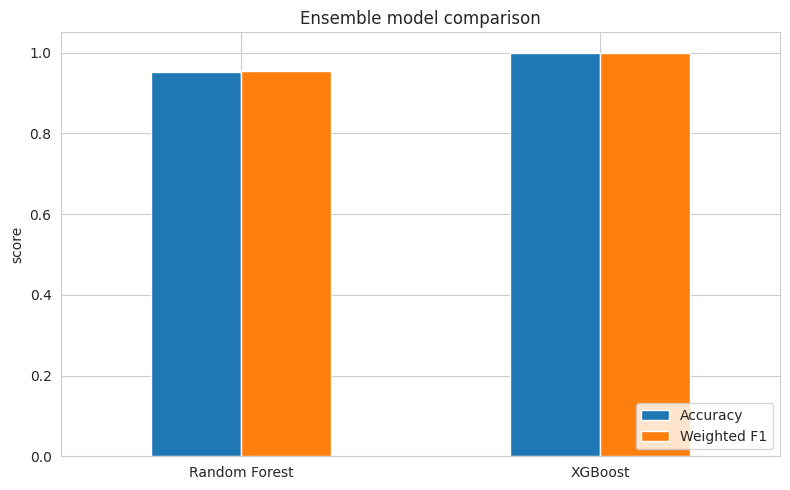

In [18]:
scores = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, rf_pred), accuracy_score(y_test, xgb_pred)],
    "Weighted F1": [f1_score(y_test, rf_pred, average="weighted"),
                    f1_score(y_test, xgb_pred, average="weighted")]},
    index=["Random Forest", "XGBoost"]).round(3)
display(scores)

scores.plot(kind="bar", ylim=(0, 1.05), rot=0)
plt.title("Ensemble model comparison"); plt.ylabel("score")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

## 11 - Insights and conclusion

**Segments discovered (K-Means)**
- Tier-1 High-Need - high child mortality, low income & GDP, short life expectancy - priority for support / at-risk group.
- Tier-2 Emerging - mid-range on every indicator - the largest, growth-stage group.
- Tier-3 Advanced - low child mortality, high income & GDP, long life expectancy - stable / premium group.

**What drives a segment (Random Forest importance)**
- `child_mort`, `gdpp`, `income`, `total_fer` and `life_expec` are the dominant levers - these are the fields to watch when scoring or moving an entity between tiers.

**Model performance**
- Both ensembles reproduce the segments almost perfectly on unseen data, so the pipeline yields a reliable classifier that can assign any new record to a tier instantly.
- Note - because the labels come from clustering the same features, very high accuracy is expected; the real value is a deployable, explainable scoring rule rather than a benchmark score.

**DBSCAN takeaway**
- Density-based clustering flags a handful of extreme records as outliers instead of forming clean tiers, it's better used here as an anomaly detector alongside the K-Means segmentation.

**Outcome** - a complete Customer Intelligence System: clustering defines the segments, ensemble classification scores new entities, and feature importance explains why - ready to drive targeted, segment-specific action.